In [1]:
# 1D CNN — Naive vs Domain-Informed preprocessing (WORKSHOP VERSION, self-contained)
#
# Same lightweight 1D CNN architecture, same training procedure, same 600/120-row
# workshop subset, for THREE preprocessing variants:
#
#   1. naive           : raw 20-channel EEG (no montage) + z-score
#   2. montage_only     : 8-channel bipolar montage        + z-score  (isolates montage)
#   3. domain_informed  : 8-channel bipolar montage        + mu-law   (montage + encoding)
#
# Running montage_only separately from domain_informed lets us tell apart two different
# effects that are otherwise bundled together: does bipolar montage alone help or hurt,
# and does adding mu-law encoding on top help or hurt further?
#
# We deliberately use a SMALL, simple CNN (not EEGNet) here: with only 600 training rows,
# a larger architecture (EEGNet has ~675K params, most of them in one wide projection layer)
# overfits almost immediately and can drown out any real signal from the preprocessing
# comparison. A smaller model with global average pooling is less prone to memorizing
# the training set, which gives the naive-vs-domain comparison a fairer chance to show
# through the noise.
#
# No 2-step training, no augmentation, no sample weighting — the workshop subset
# is already class-balanced (100 rows/class train, 20 rows/class val), so these
# imbalance-correction techniques have nothing to correct for here.
#
# Fully self-contained — no external .py imports.

In [2]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

IS_KAGGLE = os.path.exists('/kaggle')
print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Local'} | torch {torch.__version__}")

Environment: Kaggle | torch 2.10.0+cu128


In [3]:
# ============ Config ============
SEED        = 42
WINDOW_LEN  = 10000     # samples at 200 Hz = 50 seconds per window
NUM_EPOCHS  = 15        # light architecture — fast even with more epochs than the 2D CNN
BATCH_SIZE  = 32
LR          = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE    = 5

if IS_KAGGLE:
    DATA_ROOT       = '/kaggle/input/competitions/hms-harmful-brain-activity-classification'
    RAW_TRAIN_PATH  = os.path.join(DATA_ROOT, 'train.csv')
    EEG_DIR         = os.path.join(DATA_ROOT, 'train_eegs')
    SAMPLE_IDS_PATH = '/kaggle/input/datasets/xiaosufrankhu/midas-summer-academy-wk3-eeg/workshop_sample_ids.csv'
    EEG_CACHE_DIR   = '/kaggle/working/eeg_cache'
else:
    DATA_ROOT       = os.path.abspath('../')
    RAW_TRAIN_PATH  = os.path.abspath('../data_raw/train.csv')
    EEG_DIR         = os.path.join(DATA_ROOT, 'train_eegs')
    SAMPLE_IDS_PATH = os.path.abspath('../data_raw/workshop_sample_ids.csv')
    EEG_CACHE_DIR   = os.path.abspath('../eeg_cache')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

# NOTE: if running on Kaggle and this path doesn't exist, run !ls /kaggle/input
# and update DATA_ROOT / EEG_DIR to match how the competition data was attached.
print(f"Competition data path exists: {os.path.exists(DATA_ROOT)}")

Device: cuda | AMP: True
Competition data path exists: True


In [4]:
# ============ Data loading (workshop subset) ============
# workshop_sample_ids.csv only carries ID + split; merge with the raw train.csv
# to recover eeg_label_offset_seconds and vote columns for the 600/120 subset.

raw_df     = pd.read_csv(RAW_TRAIN_PATH)
sample_ids = pd.read_csv(SAMPLE_IDS_PATH)

merged = raw_df.merge(
    sample_ids[["eeg_id", "eeg_sub_id", "split"]],
    on=["eeg_id", "eeg_sub_id"],
    how="inner",
)
train_df = merged[merged["split"] == "train"].reset_index(drop=True)
val_df   = merged[merged["split"] == "val"].reset_index(drop=True)

print(f'Train: {len(train_df):,} rows')
print(f'Val   : {len(val_df):,} rows')
print(train_df['expert_consensus'].value_counts())

Train: 600 rows
Val   : 120 rows
expert_consensus
LRDA       100
LPD        100
GPD        100
Other      100
Seizure    100
GRDA       100
Name: count, dtype: int64


In [5]:
# ============ Raw EEG caching ============
# Each {eeg_id}.parquet holds the full raw recording for that eeg_id; several rows
# in train_df/val_df may share the same eeg_id but use a different label window
# (eeg_label_offset_seconds). We cache each eeg_id's raw signal as .npy once so
# repeated windows from the same recording don't re-read the parquet file.

os.makedirs(EEG_CACHE_DIR, exist_ok=True)

def cache_one_eeg(eeg_id: int, eeg_dir: str, cache_dir: str) -> None:
    dst = os.path.join(cache_dir, f"{eeg_id}.npy")
    if os.path.exists(dst):
        return
    src = os.path.join(eeg_dir, f"{eeg_id}.parquet")
    eeg = pd.read_parquet(src).to_numpy(dtype=np.float32)  # (T, 20)
    np.save(dst, eeg)

needed_eeg_ids = set(train_df['eeg_id']).union(val_df['eeg_id'])
for eeg_id in needed_eeg_ids:
    cache_one_eeg(int(eeg_id), EEG_DIR, EEG_CACHE_DIR)

print(f'Cache ready: {len(needed_eeg_ids)} raw EEG recordings for workshop subset')

Cache ready: 261 raw EEG recordings for workshop subset


In [6]:
# ============ Calibrate mu-law scale from real data ============
# mu-law assumes its input is roughly within [-1, 1] before compression. Rather than
# hardcoding a scale, we calibrate it empirically from a sample of the actual
# bipolar-montage training signal, using the 99th percentile of absolute amplitude.

def _quick_bipolar_sample(eeg_id: int, cache_dir: str) -> np.ndarray:
    eeg = np.load(os.path.join(cache_dir, f"{eeg_id}.npy")).T  # (20, T)
    return np.stack([
        eeg[0]  - eeg[5],  eeg[5]  - eeg[7],
        eeg[0]  - eeg[2],  eeg[2]  - eeg[7],
        eeg[11] - eeg[13], eeg[13] - eeg[18],
        eeg[11] - eeg[16], eeg[16] - eeg[18],
    ], axis=0)

sample_ids_for_calib = list(train_df['eeg_id'].unique())[:100]  # sample from train only, no leakage
abs_vals = []
for eeg_id in sample_ids_for_calib:
    bipolar = _quick_bipolar_sample(int(eeg_id), EEG_CACHE_DIR)
    bipolar = np.nan_to_num(bipolar, nan=0.0, posinf=0.0, neginf=0.0)  # raw HMS EEG has real NaN gaps
    abs_vals.append(np.abs(bipolar).ravel())
abs_vals = np.concatenate(abs_vals)

n_nonzero = (abs_vals > 0).sum()
print(f"Calibration sample: {len(abs_vals):,} values, {n_nonzero:,} non-zero after NaN cleanup")

MULAW_SCALE = float(np.percentile(abs_vals, 99))
assert np.isfinite(MULAW_SCALE) and MULAW_SCALE > 0, f"Bad MULAW_SCALE: {MULAW_SCALE}"
print(f"Calibrated MULAW_SCALE (99th percentile of |bipolar signal|): {MULAW_SCALE:.2f}")
print(f"(for reference, median={np.median(abs_vals):.2f}, max={abs_vals.max():.2f})")

Calibration sample: 14,588,800 values, 14,550,245 non-zero after NaN cleanup
Calibrated MULAW_SCALE (99th percentile of |bipolar signal|): 1822.86
(for reference, median=27.38, max=44623.30)


In [7]:
# ============ Preprocessing: naive vs montage-only vs domain-informed ============
# Raw parquet column order (fixed, from the HMS competition data):
#   Fp1=0, F3=1, C3=2, P3=3, F7=4, T3=5, T5=6, O1=7, Fz=8, Cz=9, Pz=10,
#   Fp2=11, F4=12, C4=13, P4=14, F8=15, T4=16, T6=17, O2=18, EKG=19

VOTE_COLS = ["seizure_vote", "lpd_vote", "gpd_vote",
             "lrda_vote",    "grda_vote", "other_vote"]


def apply_bipolar_montage(window: np.ndarray) -> np.ndarray:
    """Raw 20-channel window (20, T) -> 8 bipolar chains (8, T).
    Same electrode pairs as a standard double-banana montage used in clinical EEG reading.
    Note: only 8 of the 20 raw electrodes are used here (Fp1/Fp2, C3/C4, O1/O2, T3/T4) —
    Fz/Cz/Pz and the other frontal/temporal electrodes are dropped by this montage design."""
    return np.stack([
        window[0]  - window[5],   # Fp1-T3
        window[5]  - window[7],   # T3-O1
        window[0]  - window[2],   # Fp1-C3
        window[2]  - window[7],   # C3-O1
        window[11] - window[13],  # Fp2-C4
        window[13] - window[18],  # C4-O2
        window[11] - window[16],  # Fp2-T4
        window[16] - window[18],  # T4-O2
    ], axis=0)


def zscore_normalize(window: np.ndarray) -> np.ndarray:
    window = np.nan_to_num(window, nan=0.0, posinf=0.0, neginf=0.0)
    mean = window.mean(axis=1, keepdims=True)
    std  = window.std(axis=1, keepdims=True)
    std  = np.where(std < 1e-6, 1e-6, std)
    return (window - mean) / std


def mulaw_encode(window: np.ndarray, scale: float, mu: int = 256) -> np.ndarray:
    """Compresses the dynamic range of the signal — large deflections (e.g. seizure
    spikes) are compressed proportionally less than small background fluctuations,
    similar to how mu-law encoding preserves perceptual detail in audio.

    `scale` must be calibrated to the actual signal amplitude (see MULAW_SCALE above) —
    mu-law assumes its input is roughly within [-1, 1]; a scale that's too small pushes
    most values into the saturated extremes and destroys the detail-preserving property.
    """
    window = np.nan_to_num(window, nan=0.0, posinf=0.0, neginf=0.0)
    x = np.clip(window, -scale * 8, scale * 8) / scale
    return (np.sign(x) * np.log(1 + mu * np.abs(x))
            / np.log(mu + 1)).astype(np.float32)


class EEGWindowDataset(Dataset):
    """
    mode="naive"          : all 20 raw channels, z-score normalized
    mode="montage_only"   : 8-channel bipolar montage, z-score normalized (no mu-law)
    mode="domain_informed": 8-channel bipolar montage, mu-law encoded
    Everything else (windowing, labels) is identical across all three modes.
    """

    def __init__(self, metadata_df: pd.DataFrame, eeg_cache_dir: str,
                 mode: str, window_len: int = WINDOW_LEN):
        assert mode in ("naive", "montage_only", "domain_informed")
        self.meta       = metadata_df.reset_index(drop=True)
        self.cache_dir  = eeg_cache_dir
        self.mode       = mode
        self.window_len = window_len

        votes    = self.meta[VOTE_COLS].to_numpy(dtype=np.float32)
        row_sums = votes.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1.0, row_sums)
        self.soft_labels = votes / row_sums
        self.hard_labels = self.soft_labels.argmax(1)

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row    = self.meta.iloc[idx]
        eeg_id = int(row["eeg_id"])
        offset = int(row["eeg_label_offset_seconds"]) * 200   # 200 Hz sampling rate

        eeg = np.load(os.path.join(self.cache_dir, f"{eeg_id}.npy"))  # (T, 20)
        eeg = eeg.T                                                   # (20, T)

        window = eeg[:, offset:offset + self.window_len]
        if window.shape[1] < self.window_len:
            pad    = self.window_len - window.shape[1]
            window = np.pad(window, ((0, 0), (0, pad)), mode="constant")

        if self.mode == "naive":
            window = zscore_normalize(window)                         # (20, T)
        elif self.mode == "montage_only":
            window = apply_bipolar_montage(window)                    # (8, T)
            window = zscore_normalize(window)                         # (8, T)
        else:  # domain_informed
            window = apply_bipolar_montage(window)                    # (8, T)
            window = mulaw_encode(window, scale=MULAW_SCALE)          # (8, T)

        img   = torch.from_numpy(window.astype(np.float32))
        soft  = torch.from_numpy(self.soft_labels[idx])
        label = int(self.hard_labels[idx])
        return {"x": img, "soft_y": soft, "y": label}

In [8]:
# ============ Model: small 1D CNN (not EEGNet — see note above) ============
# Plain conv -> BN -> ReLU -> pool x3, then global average pool + linear head.
# Far fewer parameters than EEGNet (mostly because of global average pooling instead
# of a full flatten-then-project), which matters a lot when training on only 600 rows.

class TemporalCNN1D(nn.Module):
    def __init__(self, in_channels, feat_dim=256, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, padding=3)
        self.bn1   = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(256)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(256, feat_dim)

    def forward(self, x):
        # x: (B, C, T)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.drop(x)
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop(x)
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop(x)
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)  # global average pool -> (B, 256)
        return self.proj(x)


class MLPHead(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class EEGClassifier(nn.Module):
    def __init__(self, in_channels, num_classes=6, feat_dim=256):
        super().__init__()
        self.backbone = TemporalCNN1D(in_channels=in_channels, feat_dim=feat_dim)
        self.head     = MLPHead(in_dim=feat_dim, num_classes=num_classes)

    def forward(self, x):
        z = self.backbone(x)
        return self.head(z)

In [9]:
# ============ Train / eval (reusable for all runs) ============
def run_training(mode: str, in_channels: int):
    print(f"\n{'='*60}\nRun: {mode.upper()}  (in_channels={in_channels})\n{'='*60}")

    train_ds = EEGWindowDataset(train_df, EEG_CACHE_DIR, mode=mode)
    val_ds   = EEGWindowDataset(val_df,   EEG_CACHE_DIR, mode=mode)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = EEGClassifier(in_channels=in_channels, num_classes=6).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params:,}")

    criterion     = nn.KLDivLoss(reduction='batchmean')
    val_criterion = nn.CrossEntropyLoss()
    optimizer     = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler     = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler        = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    def validate():
        model.eval()
        val_ce, val_kl = 0.0, 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                x, y, soft = batch['x'].to(DEVICE), batch['y'].to(DEVICE), batch['soft_y'].to(DEVICE)
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    logits = model(x)
                val_ce += val_criterion(logits, y).item()
                val_kl += criterion(F.log_softmax(logits, dim=1), soft).item()
                all_preds.extend(logits.argmax(1).cpu().tolist())
                all_labels.extend(y.cpu().tolist())
        macro_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        per_class = f1_score(all_labels, all_preds, average=None,    zero_division=0)
        return val_kl / len(val_loader), val_ce / len(val_loader), macro_f1, per_class

    history = []
    # NOTE: "best" is defined by val KL (the competition metric), not macro F1 — this
    # matches the KL-based early stopping we use in the XGBoost notebook, so the three
    # models are all selected the same way.
    best_kl, best_f1, best_epoch, wait, best_state = float('inf'), 0.0, 0, 0, None

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        t0 = time.time()
        train_loss = 0.0
        for batch in train_loader:
            x, soft = batch['x'].to(DEVICE), batch['soft_y'].to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(x)
                loss   = criterion(F.log_softmax(logits, dim=1), soft)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        scheduler.step()

        val_kl, val_ce, macro_f1, _ = validate()
        avg_train = train_loss / len(train_loader)
        elapsed   = time.time() - t0

        history.append({'epoch': epoch, 'train_kl': avg_train, 'val_kl': val_kl,
                         'val_ce': val_ce, 'macro_f1': macro_f1})
        print(f'Epoch {epoch:03d} | train_kl {avg_train:.4f} | val_kl {val_kl:.4f} | '
              f'val_ce {val_ce:.4f} | macro_f1 {macro_f1:.4f} | {elapsed:.0f}s')

        if val_kl < best_kl:
            best_kl, best_f1, best_epoch, wait = val_kl, macro_f1, epoch, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), f'best_1d_{mode}.pt')
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    _, _, _, best_per_class = validate()  # per-class F1 at the KL-best checkpoint

    print(f"\n{mode.upper()} complete \u2014 best val_kl={best_kl:.4f} (macro_f1={best_f1:.4f}) at epoch {best_epoch}")
    return history, best_epoch, best_per_class


In [10]:
# ============ Run 1: naive (20-channel raw, z-score) ============
history_naive, naive_best_epoch, naive_per_class = run_training(mode="naive", in_channels=20)



Run: NAIVE  (in_channels=20)
Parameters: 249,030
Epoch 001 | train_kl 1.1947 | val_kl 1.2593 | val_ce 1.8433 | macro_f1 0.0661 | 4s
Epoch 002 | train_kl 0.8900 | val_kl 1.2243 | val_ce 1.7036 | macro_f1 0.2610 | 1s
Epoch 003 | train_kl 0.7318 | val_kl 1.4816 | val_ce 1.9270 | macro_f1 0.1257 | 1s
Epoch 004 | train_kl 0.6652 | val_kl 1.4641 | val_ce 1.9021 | macro_f1 0.2429 | 2s
Epoch 005 | train_kl 0.6018 | val_kl 1.4642 | val_ce 1.9729 | macro_f1 0.1409 | 2s
Epoch 006 | train_kl 0.5316 | val_kl 1.5803 | val_ce 2.0928 | macro_f1 0.1516 | 2s
Epoch 007 | train_kl 0.4780 | val_kl 1.7534 | val_ce 2.2336 | macro_f1 0.1712 | 1s
Early stopping at epoch 7

NAIVE complete — best macro_f1=0.2610 at epoch 2


In [11]:
# ============ Run 2: montage-only (8-channel bipolar montage, z-score, no mu-law) ============
history_montage, montage_best_epoch, montage_per_class = run_training(mode="montage_only", in_channels=8)



Run: MONTAGE_ONLY  (in_channels=8)
Parameters: 243,654
Epoch 001 | train_kl 1.3193 | val_kl 1.1864 | val_ce 1.7522 | macro_f1 0.1147 | 1s
Epoch 002 | train_kl 0.9774 | val_kl 1.2766 | val_ce 1.7576 | macro_f1 0.1668 | 1s
Epoch 003 | train_kl 0.7511 | val_kl 1.3055 | val_ce 1.8274 | macro_f1 0.2606 | 1s
Epoch 004 | train_kl 0.6256 | val_kl 1.3729 | val_ce 1.9023 | macro_f1 0.2708 | 1s
Epoch 005 | train_kl 0.5782 | val_kl 1.4607 | val_ce 2.0918 | macro_f1 0.2083 | 1s
Epoch 006 | train_kl 0.5027 | val_kl 1.6223 | val_ce 2.1804 | macro_f1 0.3264 | 1s
Epoch 007 | train_kl 0.4580 | val_kl 1.5189 | val_ce 2.1743 | macro_f1 0.2203 | 1s
Epoch 008 | train_kl 0.3889 | val_kl 1.5765 | val_ce 2.1401 | macro_f1 0.2479 | 1s
Epoch 009 | train_kl 0.4123 | val_kl 1.5973 | val_ce 2.1782 | macro_f1 0.2327 | 1s
Epoch 010 | train_kl 0.3417 | val_kl 1.6663 | val_ce 2.2290 | macro_f1 0.2392 | 1s
Epoch 011 | train_kl 0.2938 | val_kl 1.6676 | val_ce 2.2668 | macro_f1 0.2370 | 1s
Early stopping at epoch 11

MON

In [12]:
# ============ Run 3: domain-informed (8-channel bipolar montage, mu-law) ============
history_domain, domain_best_epoch, domain_per_class = run_training(mode="domain_informed", in_channels=8)



Run: DOMAIN_INFORMED  (in_channels=8)
Parameters: 243,654
Epoch 001 | train_kl 1.1126 | val_kl 1.2289 | val_ce 1.8118 | macro_f1 0.1327 | 1s
Epoch 002 | train_kl 0.8187 | val_kl 1.4413 | val_ce 2.0571 | macro_f1 0.2651 | 1s
Epoch 003 | train_kl 0.7037 | val_kl 1.7455 | val_ce 2.4058 | macro_f1 0.2579 | 1s
Epoch 004 | train_kl 0.6351 | val_kl 1.7490 | val_ce 2.3838 | macro_f1 0.1378 | 1s
Epoch 005 | train_kl 0.5932 | val_kl 1.9955 | val_ce 2.7466 | macro_f1 0.1454 | 1s
Epoch 006 | train_kl 0.5211 | val_kl 2.1435 | val_ce 2.8745 | macro_f1 0.1016 | 1s
Epoch 007 | train_kl 0.4760 | val_kl 2.3527 | val_ce 3.1528 | macro_f1 0.0782 | 1s
Early stopping at epoch 7

DOMAIN_INFORMED complete — best macro_f1=0.2651 at epoch 2


### Final report: domain-informed run (standard format)

This is the run used as the starting point for Tweak & Compare below.


In [ ]:
# ============ Final report: domain-informed run (standard format) ============
CLASS_NAMES = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]

epochs_d   = [h["epoch"]    for h in history_domain]
train_kl_d = [h["train_kl"] for h in history_domain]
val_kl_d   = [h["val_kl"]   for h in history_domain]
val_ce_d   = [h["val_ce"]   for h in history_domain]
f1_d       = [h["macro_f1"] for h in history_domain]

domain_val_kl = next(h["val_kl"]   for h in history_domain if h["epoch"] == domain_best_epoch)
domain_val_f1 = next(h["macro_f1"] for h in history_domain if h["epoch"] == domain_best_epoch)

print(f"Val macro F1     : {domain_val_f1:.4f}")
print(f"Val KL divergence: {domain_val_kl:.4f}")
print(f"(random-guess baseline for 6 balanced classes: macro F1 \u2248 0.167)")
print("\nPer-class F1 (domain-informed, best epoch):")
for name, f in zip(CLASS_NAMES, domain_per_class):
    print(f"  {name:<10} {f:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(epochs_d, train_kl_d, label="train KL (loss)")
axes[0, 0].plot(epochs_d, val_kl_d,   label="val KL (loss)")
axes[0, 0].axvline(domain_best_epoch, color="red", linestyle="--", label=f"best={domain_best_epoch}")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("KL Divergence (loss)")
axes[0, 0].set_title("Train/Val KL loss"); axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(epochs_d, val_ce_d, color="orange")
axes[0, 1].axvline(domain_best_epoch, color="red", linestyle="--", label=f"best={domain_best_epoch}")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Cross-Entropy")
axes[0, 1].set_title("Val CE (monitoring)"); axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(epochs_d, f1_d, color="seagreen")
axes[1, 0].axhline(1/6, color="gray", linestyle="--", linewidth=1, label="random guess")
axes[1, 0].axvline(domain_best_epoch, color="red", linestyle="--", label=f"best={domain_best_epoch}")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Val Macro F1")
axes[1, 0].set_title("Val Macro F1"); axes[1, 0].legend(fontsize=8)

axes[1, 1].bar(CLASS_NAMES, domain_per_class, color="steelblue")
axes[1, 1].axhline(domain_val_f1, color="red", linestyle="--", label=f"macro F1 = {domain_val_f1:.3f}")
axes[1, 1].set_ylim(0, 1); axes[1, 1].set_ylabel("F1")
axes[1, 1].set_title(f"Per-class F1 (val, epoch {domain_best_epoch})"); axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("cnn1d_domain_workshop_eval.png", dpi=150)
plt.show()


Metric                     Naive    Montage-only   Domain-informed
------------------------------------------------------------------
Best val KL               1.2243          1.1864            1.2289
Best macro F1             0.2610          0.3264            0.2651

(random-guess baseline for 6 balanced classes: macro F1 ≈ 0.167)


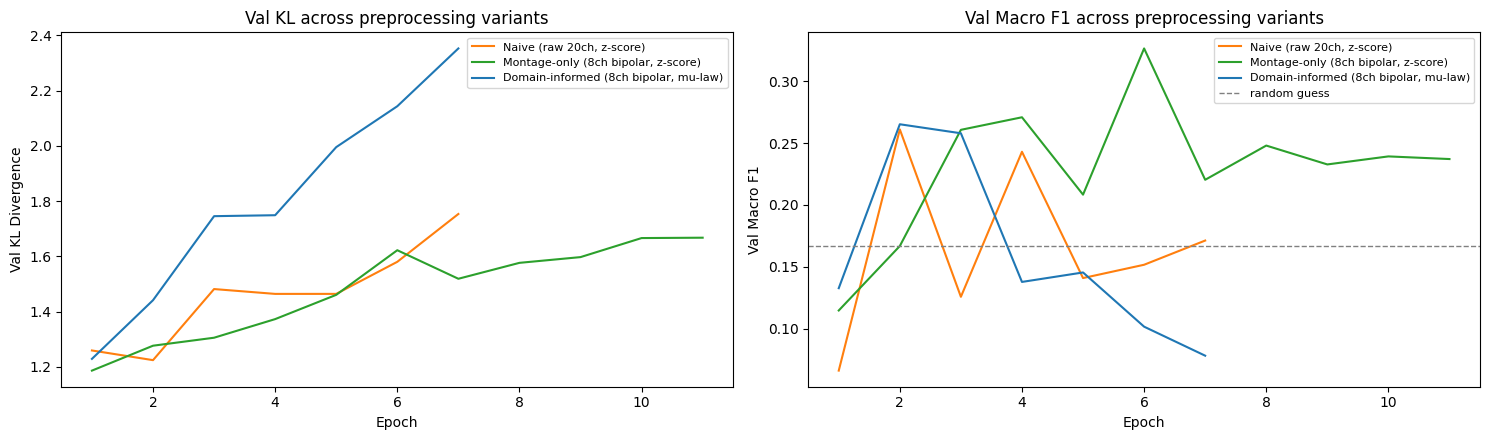

In [13]:
# ============ Comparison across preprocessing variants ============
def best_metrics(history):
    best = min(history, key=lambda h: h["val_kl"])  # KL-based selection, matches XGBoost notebook
    return best["macro_f1"], best["epoch"], best["val_kl"]

naive_f1,   naive_epoch,   naive_kl   = best_metrics(history_naive)
montage_f1, montage_epoch, montage_kl = best_metrics(history_montage)
domain_f1,  domain_epoch,  domain_kl  = best_metrics(history_domain)

print(f"{'Metric':<20}{'Naive':>12}{'Montage-only':>16}{'Domain-informed':>18}")
print(f"{'-'*66}")
print(f"{'Best val KL':<20}{naive_kl:>12.4f}{montage_kl:>16.4f}{domain_kl:>18.4f}")
print(f"{'Best macro F1':<20}{naive_f1:>12.4f}{montage_f1:>16.4f}{domain_f1:>18.4f}")
print(f"\n(random-guess baseline for 6 balanced classes: macro F1 \u2248 0.167)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

runs = [
    ('Naive (raw 20ch, z-score)',            history_naive,   'tab:orange'),
    ('Montage-only (8ch bipolar, z-score)',  history_montage, 'tab:green'),
    ('Domain-informed (8ch bipolar, mu-law)', history_domain,  'tab:blue'),
]

for label, history, color in runs:
    ax1.plot([h['epoch'] for h in history], [h['val_kl'] for h in history], label=label, color=color)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val KL Divergence')
ax1.set_title('Val KL across preprocessing variants'); ax1.legend(fontsize=8)

for label, history, color in runs:
    ax2.plot([h['epoch'] for h in history], [h['macro_f1'] for h in history], label=label, color=color)
ax2.axhline(1/6, color='gray', linestyle='--', linewidth=1, label='random guess')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Macro F1')
ax2.set_title('Val Macro F1 across preprocessing variants'); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('naive_vs_domain_1d_workshop.png', dpi=150)
plt.show()


## Tweak & Compare (~20 min)

Pick 1-2 changes below, rerun the cell, and log your result in the shared sheet.
This reuses `run_training()` from above, so any of the three preprocessing modes
can be selected as one of the "tweaks".

| Knob | Default | Try |
|---|---|---|
| learning rate | 1e-3 | 3e-4 / 3e-3 |
| dropout | 0.2 | 0.0 / 0.4 |
| preprocessing mode | domain_informed | naive / montage_only |

**Log your run:** What you changed | Val F1 | Val KL | one-line observation


In [ ]:
# ============ Tweak & Compare ============
TWEAK_LR      = 1e-3               # <- change me (try 3e-4 or 3e-3)
TWEAK_DROPOUT = 0.2                # <- change me (try 0.0 or 0.4)
TWEAK_MODE    = "domain_informed"  # <- change me ("naive" / "montage_only" / "domain_informed")
TWEAK_IN_CHANNELS = {"naive": 20, "montage_only": 8, "domain_informed": 8}[TWEAK_MODE]


def run_training_tweak(mode, in_channels, lr, dropout):
    train_ds = EEGWindowDataset(train_df, EEG_CACHE_DIR, mode=mode)
    val_ds   = EEGWindowDataset(val_df,   EEG_CACHE_DIR, mode=mode)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = EEGClassifier(in_channels=in_channels, num_classes=6)
    model.backbone = TemporalCNN1D(in_channels=in_channels, dropout=dropout)  # apply tweak dropout
    model = model.to(DEVICE)

    criterion     = nn.KLDivLoss(reduction='batchmean')
    val_criterion = nn.CrossEntropyLoss()
    optimizer     = AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler     = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler        = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    best_kl, best_f1, wait = float('inf'), 0.0, 0
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        for batch in train_loader:
            x, soft = batch['x'].to(DEVICE), batch['soft_y'].to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(x)
                loss   = criterion(F.log_softmax(logits, dim=1), soft)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()

        model.eval()
        val_kl_sum = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                x, y, soft = batch['x'].to(DEVICE), batch['y'].to(DEVICE), batch['soft_y'].to(DEVICE)
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    logits = model(x)
                val_kl_sum += criterion(F.log_softmax(logits, dim=1), soft).item()
                all_preds.extend(logits.argmax(1).cpu().tolist())
                all_labels.extend(y.cpu().tolist())
        val_kl   = val_kl_sum / len(val_loader)
        macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        if val_kl < best_kl:
            best_kl, best_f1, wait = val_kl, macro_f1, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    return best_f1, best_kl


tweak_f1, tweak_kl = run_training_tweak(TWEAK_MODE, TWEAK_IN_CHANNELS, TWEAK_LR, TWEAK_DROPOUT)
print(f"lr={TWEAK_LR} | dropout={TWEAK_DROPOUT} | mode={TWEAK_MODE}")
print(f"Val macro F1 : {tweak_f1:.4f}")
print(f"Val KL       : {tweak_kl:.4f}")
print("-> log this row in the shared sheet: what you changed / F1 / KL / one-line observation")


### Done early? Extend (~10 min)

**Task:** add one more conv block (or a 4th channel width stage) to `TemporalCNN1D` and see
if it changes val F1 / KL for the domain-informed mode. Watch for overfitting — this is a
600-row dataset, so a deeper network isn't automatically better.

**Copy-paste prompt for Claude / ChatGPT:**

> Here is my 1D CNN backbone for EEG classification: [paste the `TemporalCNN1D` class from
> earlier in this notebook]. Add one more conv block (Conv1d -> BatchNorm1d -> ReLU ->
> Dropout -> MaxPool1d) between the existing conv2 and conv3 blocks, with 192 output
> channels. Keep the global average pooling and the final `proj` layer working with
> the new channel count. Return the full updated class.

Paste the AI's code into the cell below, run it, then rerun `run_training_tweak` with your
new backbone and compare F1/KL against the baseline above. If you get stuck for more than
~5 minutes, run the reference solution cell after this one.


In [ ]:
# ============ Your extended TemporalCNN1D goes here ============
# Paste the class Claude/ChatGPT gives you in response to the prompt above, e.g.:
#
# class TemporalCNN1DExtended(nn.Module):
#     ...
#
# then swap it into run_training_tweak (replace TemporalCNN1D with your new class)
# and compare F1/KL against the 3-conv-block baseline above.


### Reference solution (only look if you're stuck)


In [ ]:
# ============ Reference solution ============
class TemporalCNN1DExtended(nn.Module):
    """Same as TemporalCNN1D, plus one extra conv block (192 channels) between
    the existing conv2 and conv3 blocks."""

    def __init__(self, in_channels, feat_dim=256, dropout=0.2):
        super().__init__()
        self.conv1  = nn.Conv1d(in_channels, 64, kernel_size=7, padding=3)
        self.bn1    = nn.BatchNorm1d(64)
        self.conv2  = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2    = nn.BatchNorm1d(128)
        self.conv2b = nn.Conv1d(128, 192, kernel_size=3, padding=1)   # NEW block
        self.bn2b   = nn.BatchNorm1d(192)
        self.conv3  = nn.Conv1d(192, 256, kernel_size=3, padding=1)
        self.bn3    = nn.BatchNorm1d(256)
        self.drop   = nn.Dropout(dropout)
        self.proj   = nn.Linear(256, feat_dim)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.drop(x)
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop(x)
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn2b(self.conv2b(x)))   # NEW block, no extra pooling
        x = self.drop(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop(x)
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
        return self.proj(x)


def run_training_extended(mode, in_channels, lr=LR, dropout=0.2):
    train_ds = EEGWindowDataset(train_df, EEG_CACHE_DIR, mode=mode)
    val_ds   = EEGWindowDataset(val_df,   EEG_CACHE_DIR, mode=mode)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    backbone = TemporalCNN1DExtended(in_channels=in_channels, dropout=dropout)
    head     = MLPHead(in_dim=256, num_classes=6)
    model    = nn.Sequential(backbone, head).to(DEVICE)

    criterion = nn.KLDivLoss(reduction='batchmean')
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    best_kl, best_f1, wait = float('inf'), 0.0, 0
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        for batch in train_loader:
            x, soft = batch['x'].to(DEVICE), batch['soft_y'].to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(x)
                loss   = criterion(F.log_softmax(logits, dim=1), soft)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()

        model.eval()
        val_kl_sum = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                x, y, soft = batch['x'].to(DEVICE), batch['y'].to(DEVICE), batch['soft_y'].to(DEVICE)
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    logits = model(x)
                val_kl_sum += criterion(F.log_softmax(logits, dim=1), soft).item()
                all_preds.extend(logits.argmax(1).cpu().tolist())
                all_labels.extend(y.cpu().tolist())
        val_kl   = val_kl_sum / len(val_loader)
        macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        if val_kl < best_kl:
            best_kl, best_f1, wait = val_kl, macro_f1, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    return best_f1, best_kl


ext_f1, ext_kl = run_training_extended("domain_informed", 8)
print(f"3-conv-block baseline (from Metrics above)  vs  4-conv-block extended")
print(f"Extended -> Val F1: {ext_f1:.4f} | Val KL: {ext_kl:.4f}")
